In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv('Video_Games.csv')

In [3]:
df.head()

,index,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,index,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
16923,16923,Aliens: Colonial Marines,PS3,2013.0,Shooter,Sega,0.20,0.29,0.00,0.11,0.6,43.0,25.0,3.6,295.0,Gearbox Software,M
16924,16924,Backyard Wrestling: Don't Try This at Home,PS2,2003.0,Fighting,Eidos Interactive,0.30,0.23,0.00,0.08,0.6,51.0,24.0,7.8,29.0,Paradox Development,M
16925,16925,Yakuza: Dead Souls,PS3,2011.0,Shooter,Sega,0.09,0.06,0.42,0.03,0.6,64.0,55.0,7.4,69.0,Ryu ga Gotoku Studios,M
16926,16926,Fight Night Round 2,XB,2005.0,Fighting,Electronic Arts,0.42,0.16,0.00,0.02,0.6,88.0,48.0,8.8,27.0,EA Sports,T
16927,16927,MonHun Nikki: Poka Poka Ailu Mura,PSP,2010.0,Role-Playing,Capcom,0.00,0.00,0.60,0.00,0.6,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16928 entries, 0 to 16927
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            16928 non-null  int64  
 1   Name             16926 non-null  object 
 2   Platform         16928 non-null  object 
 3   Year_of_Release  16655 non-null  float64
 4   Genre            16926 non-null  object 
 5   Publisher        16873 non-null  object 
 6   NA_Sales         16928 non-null  float64
 7   EU_Sales         16928 non-null  float64
 8   JP_Sales         16928 non-null  float64
 9   Other_Sales      16928 non-null  float64
 10  Global_Sales     16928 non-null  float64
 11  Critic_Score     8260 non-null   float64
 12  Critic_Count     8260 non-null   float64
 13  User_Score       10159 non-null  object 
 14  User_Count       7718 non-null   float64
 15  Developer        10240 non-null  object 
 16  Rating           10092 non-null  object 
dtypes: float64(9

In [6]:
df.columns

Index(['index', 'Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher',
       'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales',
       'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Developer',
       'Rating'],
      dtype='object')

In [7]:
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
print(genre_sales)

Genre
Action          1771.73
Sports          1350.61
Shooter         1086.67
Role-Playing     958.62
Platform         850.73
Misc             830.19
Racing           757.92
Fighting         467.91
Simulation       394.12
Puzzle           243.65
Adventure        240.21
Strategy         178.22
Name: Global_Sales, dtype: float64


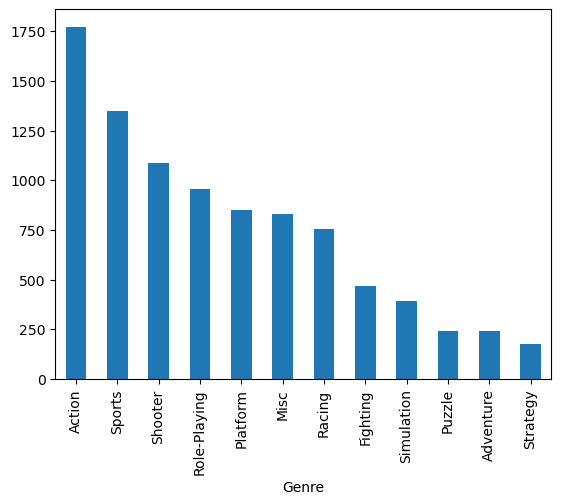

In [8]:
genre_sales.plot(kind='bar');

In [9]:
region_sales = df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
print(region_sales)

NA_Sales       4509.45
EU_Sales       2485.88
JP_Sales       1323.27
Other_Sales     810.19
dtype: float64


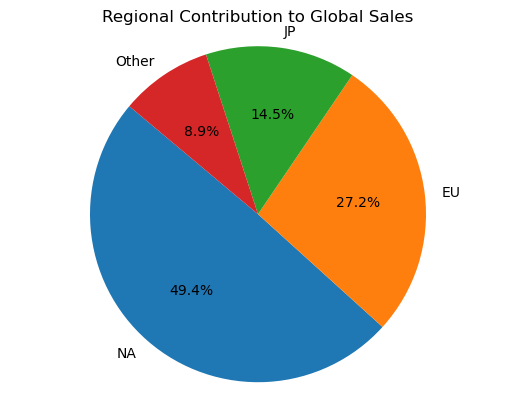

In [10]:
plt.pie(
    region_sales,
    labels=['NA','EU','JP','Other'],
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Regional Contribution to Global Sales")
plt.axis('equal')  
plt.show()

In [11]:
top_publishers = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)
print(top_publishers)

Publisher
Nintendo                        1830.35
Electronic Arts                 1155.88
Activision                       742.39
Sony Computer Entertainment      634.45
Ubisoft                          493.05
Take-Two Interactive             406.92
THQ                              342.74
Konami Digital Entertainment     284.90
Sega                             275.89
Namco Bandai Games               260.85
Name: Global_Sales, dtype: float64


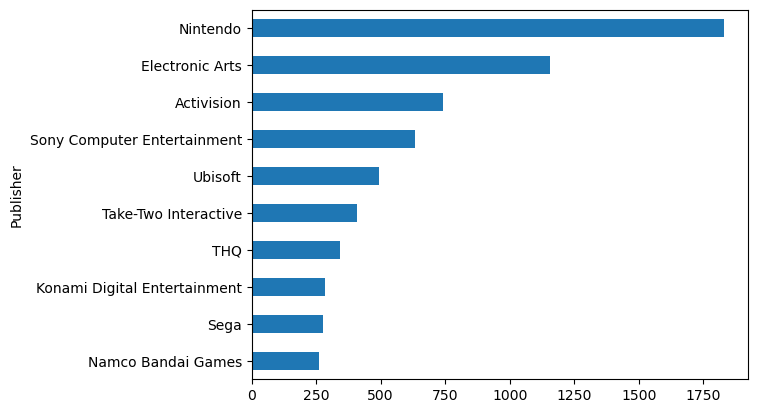

In [12]:
top_publishers.sort_values(ascending=True).plot(kind='barh');

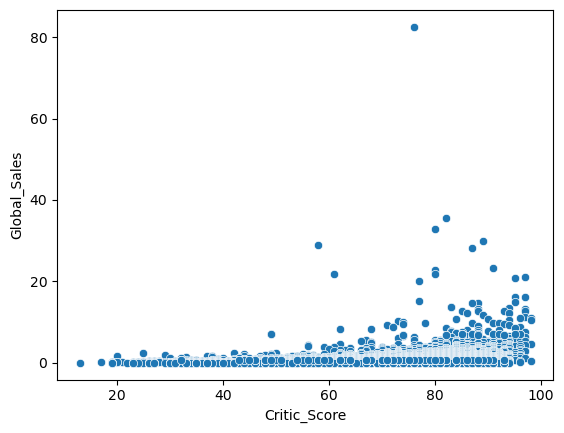

In [13]:
sns.scatterplot(data=df, x='Critic_Score', y='Global_Sales');

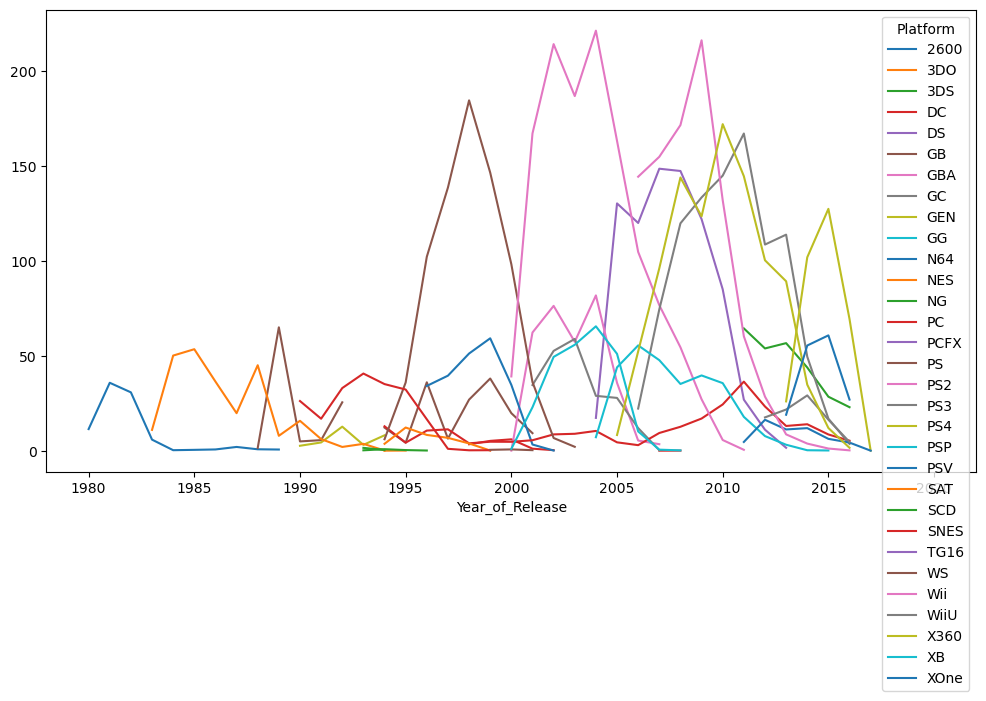

In [14]:
platform_trend = df.groupby(['Year_of_Release','Platform'])['Global_Sales'].sum().unstack();
platform_trend.plot(figsize=(12,6));

In [15]:
df.groupby(['Platform','Year_of_Release'])['Global_Sales'].mean()

Platform  Year_of_Release
2600      1980.0             1.264444
          1981.0             0.777609
          1982.0             0.787949
          1983.0             0.530000
          1984.0             0.270000
                               ...   
XB        2008.0             0.180000
XOne      2013.0             0.996842
          2014.0             0.879206
          2015.0             0.749753
          2016.0             0.299000
Name: Global_Sales, Length: 241, dtype: float64

In [16]:
df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False)

Platform
PS2     1283.08
X360     988.36
PS3      962.71
Wii      937.27
DS       813.86
PS       759.88
GBA      327.11
PS4      324.48
PSP      298.02
3DS      271.21
PC       263.47
XB       263.20
GB       256.07
NES      251.07
N64      222.64
GC       217.08
SNES     201.92
XOne     161.97
2600      98.95
WiiU      89.25
PSV       54.76
SAT       34.83
GEN       30.78
DC        15.97
SCD        1.87
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: Global_Sales, dtype: float64

In [17]:
corr = df[['NA_Sales','EU_Sales','JP_Sales','Global_Sales','Critic_Score','User_Score']].corr()
print(corr)

              NA_Sales  EU_Sales  JP_Sales  Global_Sales  Critic_Score
NA_Sales      1.000000  0.767038  0.450361      0.941405      0.242378
EU_Sales      0.767038  1.000000  0.434405      0.901956      0.221863
JP_Sales      0.450361  0.434405  1.000000      0.611950      0.155022
Global_Sales  0.941405  0.901956  0.611950      1.000000      0.247059
Critic_Score  0.242378  0.221863  0.155022      0.247059      1.000000


C:\Users\user\AppData\Local\Temp\ipykernel_14584\534248337.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df[['NA_Sales','EU_Sales','JP_Sales','Global_Sales','Critic_Score','User_Score']].corr()


In [18]:

df_model = df.dropna(subset=['Global_Sales','Critic_Score','User_Score'])

# Convert User Score to numeric
df_model['User_Score'] = pd.to_numeric(df_model['User_Score'], errors='coerce')

df_model = df_model.dropna()

C:\Users\user\AppData\Local\Temp\ipykernel_14584\881527857.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['User_Score'] = pd.to_numeric(df_model['User_Score'], errors='coerce')


In [19]:
features = ['Genre','Platform','Critic_Score','User_Score','Year_of_Release']
target = 'Global_Sales'

X = df_model[features]
y = np.log1p(df_model['Global_Sales'])

In [20]:
X = pd.get_dummies(X, columns=['Genre','Platform'], drop_first=True)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [23]:
y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R² Score:", r2)

MAE: 0.2516005466884776
R² Score: 0.4198980929134525


In [25]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

Critic_Score       0.329484
User_Score         0.187999
Year_of_Release    0.138691
Platform_PC        0.054913
Platform_Wii       0.022472
Genre_Sports       0.021866
Genre_Shooter      0.021628
Genre_Racing       0.019017
Genre_Misc         0.018572
Platform_XB        0.017404
dtype: float64

In [26]:
df['Hit'] = df['Global_Sales'] > 1 
df['Hit'].value_counts(normalize=True)

False    0.877599
True     0.122401
Name: Hit, dtype: float64

In [27]:
df.groupby('Genre')[['NA_Sales','EU_Sales','JP_Sales']].sum()

,NA_Sales,EU_Sales,JP_Sales
Genre,,,
Action,893.89,526.25,163.51
Adventure,106.06,64.12,53.22
Fighting,233.86,104.87,91.83
Misc,421.86,220.73,109.36
Platform,457.00,207.10,133.83
Puzzle,122.88,50.01,57.93
Racing,373.12,246.78,59.19
Role-Playing,338.81,194.68,363.56
Shooter,608.07,329.20,40.64


In [28]:
df.groupby('Platform')['Year_of_Release'].agg(['min','max'])

,min,max
Platform,,
2600,1980.0,1989.0
3DO,1994.0,1995.0
3DS,2011.0,2016.0
DC,1998.0,2008.0
DS,1985.0,2020.0
GB,1988.0,2001.0
GBA,2000.0,2007.0
GC,2001.0,2007.0
GEN,1990.0,1994.0
